In [1]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn

In [2]:
#Load & Explore the Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv("Airlines.csv")

# Step 1 — Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Shape: (539383, 9)

Columns: ['id', 'Airline', 'Flight', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Time', 'Length', 'Delay']

Data Types:
 id              int64
Airline        object
Flight          int64
AirportFrom    object
AirportTo      object
DayOfWeek       int64
Time            int64
Length          int64
Delay           int64
dtype: object

First 5 rows:
    id Airline  Flight AirportFrom AirportTo  DayOfWeek  Time  Length  Delay
0   1      CO     269         SFO       IAH          3    15     205      1
1   2      US    1558         PHX       CLT          3    15     222      1
2   3      AA    2400         LAX       DFW          3    20     165      1
3   4      AA    2466         SFO       DFW          3    20     195      1
4   5      AS     108         ANC       SEA          3    30     202      0


In [4]:
#Data Cleaning

In [5]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Basic statistics
print("\nStatistics:\n", df.describe())

Missing values:
 id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64

Duplicate rows: 0

Statistics:
                   id         Flight      DayOfWeek           Time  \
count  539383.000000  539383.000000  539383.000000  539383.000000   
mean   269692.000000    2427.928630       3.929668     802.728963   
std    155706.604461    2067.429837       1.914664     278.045911   
min         1.000000       1.000000       1.000000      10.000000   
25%    134846.500000     712.000000       2.000000     565.000000   
50%    269692.000000    1809.000000       4.000000     795.000000   
75%    404537.500000    3745.000000       5.000000    1035.000000   
max    539383.000000    7814.000000       7.000000    1439.000000   

              Length          Delay  
count  539383.000000  539383.000000  
mean      132.202007       0.445442  
std        70.117016       0.497015  
min       

In [6]:
#EDA 

Total Flights: 539,383
Delayed Flights: 240,264
On-Time Flights: 299,119
Delay Rate: 44.5%


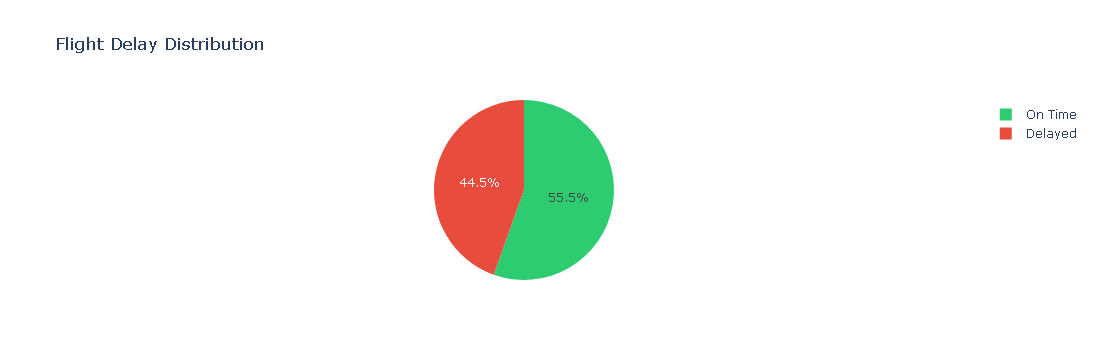

In [7]:
# Overall delay percentage
delay_counts = df["Delay"].value_counts()
delay_pct = df["Delay"].mean() * 100

print(f"Total Flights: {len(df):,}")
print(f"Delayed Flights: {delay_counts[1]:,}")
print(f"On-Time Flights: {delay_counts[0]:,}")
print(f"Delay Rate: {delay_pct:.1f}%")

# Pie chart
fig = px.pie(values=delay_counts.values,
             names=["On Time", "Delayed"],
             title="Flight Delay Distribution",
             color_discrete_sequence=["#2ecc71", "#e74c3c"])
fig.show()

In [8]:
#Delay by Airline

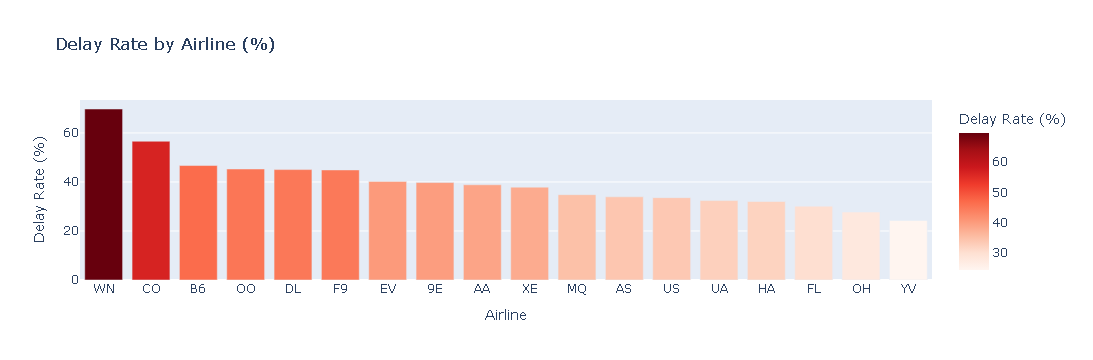

In [9]:
airline_delay = df.groupby("Airline")["Delay"].mean() * 100
airline_delay = airline_delay.sort_values(ascending=False).reset_index()
airline_delay.columns = ["Airline", "Delay_Rate"]

fig = px.bar(airline_delay,
             x="Airline",
             y="Delay_Rate",
             title="Delay Rate by Airline (%)",
             color="Delay_Rate",
             color_continuous_scale="Reds",
             labels={"Delay_Rate": "Delay Rate (%)"})
fig.show()

In [10]:
#Delay by Day of Week

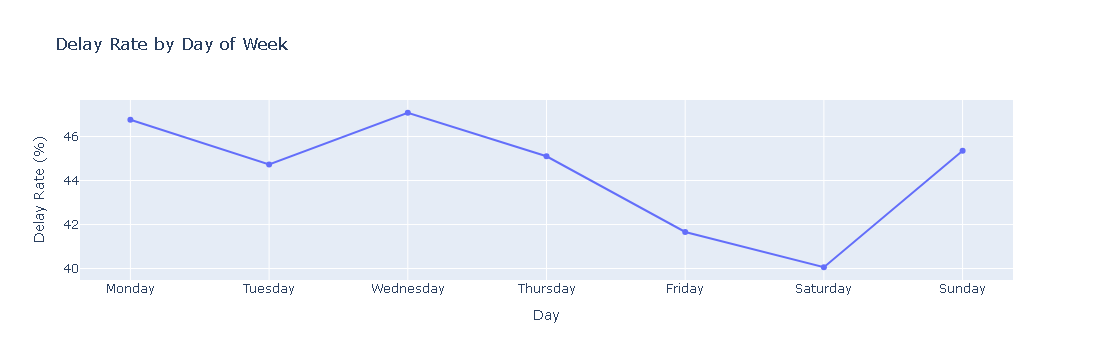

In [11]:
day_map = {1:"Monday", 2:"Tuesday", 3:"Wednesday",
           4:"Thursday", 5:"Friday", 6:"Saturday", 7:"Sunday"}

df["DayName"] = df["DayOfWeek"].map(day_map)

day_delay = df.groupby("DayName")["Delay"].mean() * 100
day_delay = day_delay.reset_index()
day_delay.columns = ["Day", "Delay_Rate"]

# Keep correct order
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_delay["Day"] = pd.Categorical(day_delay["Day"], categories=day_order, ordered=True)
day_delay = day_delay.sort_values("Day")

fig = px.line(day_delay,
              x="Day",
              y="Delay_Rate",
              title="Delay Rate by Day of Week",
              markers=True,
              labels={"Delay_Rate": "Delay Rate (%)"})
fig.show()

In [12]:
#Delay by Time of Day

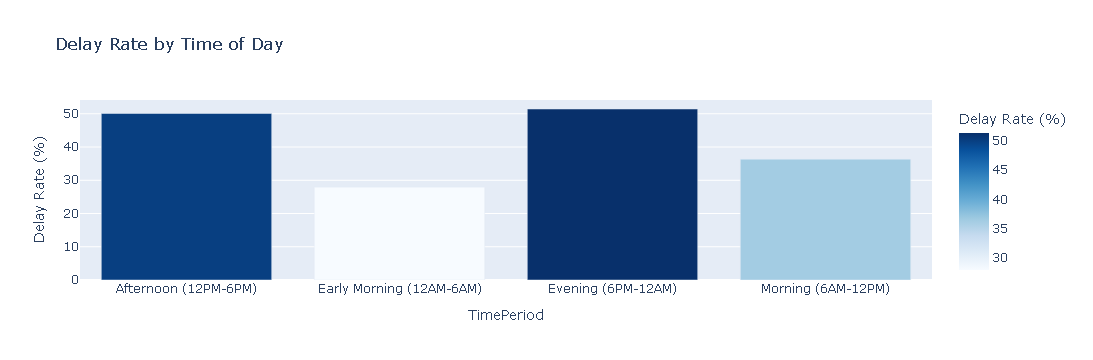

In [13]:
# Convert time (minutes since midnight) to time periods
def time_period(t):
    if t < 360:   return "Early Morning (12AM-6AM)"
    elif t < 720: return "Morning (6AM-12PM)"
    elif t < 1080:return "Afternoon (12PM-6PM)"
    else:         return "Evening (6PM-12AM)"

df["TimePeriod"] = df["Time"].apply(time_period)

time_delay = df.groupby("TimePeriod")["Delay"].mean() * 100
time_delay = time_delay.reset_index()
time_delay.columns = ["TimePeriod", "Delay_Rate"]

fig = px.bar(time_delay,
             x="TimePeriod",
             y="Delay_Rate",
             title="Delay Rate by Time of Day",
             color="Delay_Rate",
             color_continuous_scale="Blues",
             labels={"Delay_Rate": "Delay Rate (%)"})
fig.show()

In [14]:
#Flight Length vs Delay

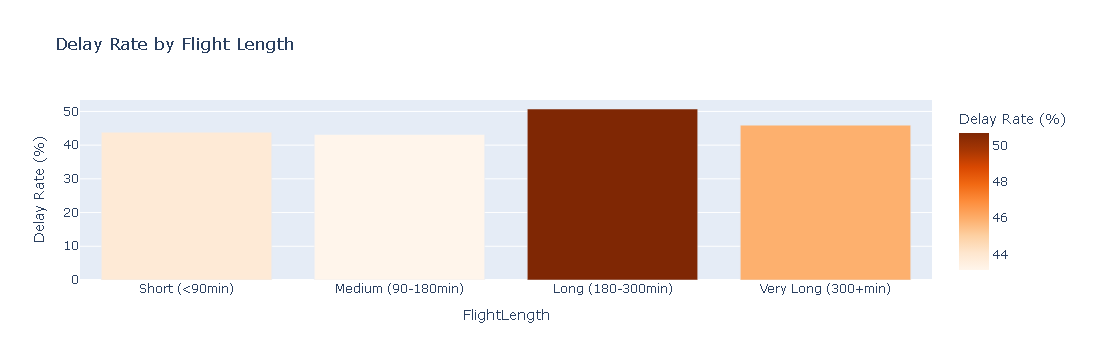

In [15]:
# Bin flight length into categories
df["LengthCategory"] = pd.cut(df["Length"],
                               bins=[0, 90, 180, 300, 700],
                               labels=["Short (<90min)",
                                       "Medium (90-180min)",
                                       "Long (180-300min)",
                                       "Very Long (300+min)"])

length_delay = df.groupby("LengthCategory")["Delay"].mean() * 100
length_delay = length_delay.reset_index()
length_delay.columns = ["FlightLength", "Delay_Rate"]

fig = px.bar(length_delay,
             x="FlightLength",
             y="Delay_Rate",
             title="Delay Rate by Flight Length",
             color="Delay_Rate",
             color_continuous_scale="Oranges",
             labels={"Delay_Rate": "Delay Rate (%)"})
fig.show()

In [16]:
#Top 10 Most Delayed Routes

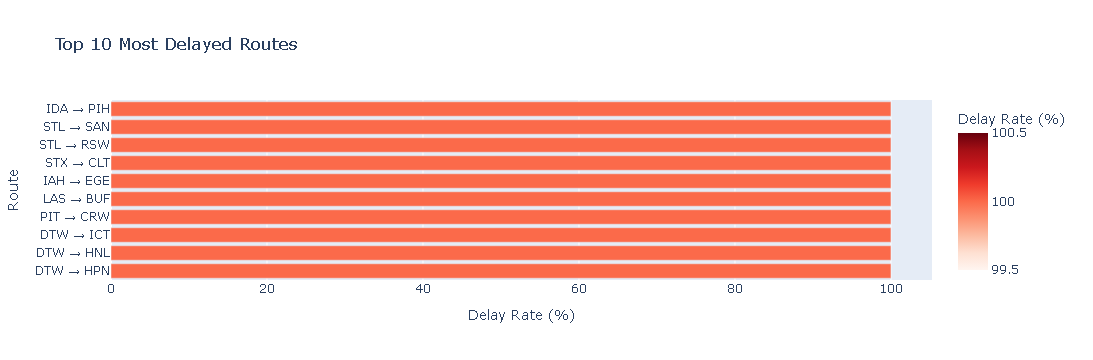

In [17]:
df["Route"] = df["AirportFrom"] + " → " + df["AirportTo"]

route_delay = df.groupby("Route")["Delay"].mean() * 100
route_delay = route_delay.sort_values(ascending=False).head(10).reset_index()
route_delay.columns = ["Route", "Delay_Rate"]

fig = px.bar(route_delay,
             x="Delay_Rate",
             y="Route",
             orientation="h",
             title="Top 10 Most Delayed Routes",
             color="Delay_Rate",
             color_continuous_scale="Reds",
             labels={"Delay_Rate": "Delay Rate (%)"})
fig.update_layout(yaxis={"categoryorder":"total ascending"})
fig.show()

In [19]:
#ML Model (Build Prediction Model)

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Encode categorical columns
df_model = pd.get_dummies(df[["Airline","DayOfWeek","Time","Length","Delay"]],
                           columns=["Airline"])

# Features and target
X = df_model.drop("Delay", axis=1)
y = df_model["Delay"]

# Split — use 20% for speed with large dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Results
print("\n--- Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training samples: 431,506
Test samples: 107,877

--- Model Results ---
Accuracy: 63.34%

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.79      0.70     59879
           1       0.62      0.44      0.52     47998

    accuracy                           0.63    107877
   macro avg       0.63      0.61      0.61    107877
weighted avg       0.63      0.63      0.62    107877



In [21]:
#Confusion Matrix

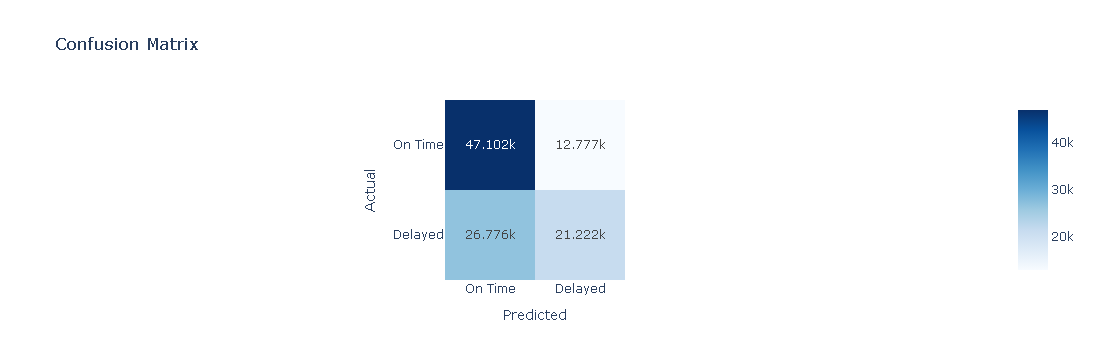

In [22]:
cm = confusion_matrix(y_test, y_pred)

fig = px.imshow(cm,
                labels=dict(x="Predicted", y="Actual"),
                x=["On Time", "Delayed"],
                y=["On Time", "Delayed"],
                title="Confusion Matrix",
                color_continuous_scale="Blues",
                text_auto=True)
fig.show()

In [24]:
#Project Summary Cell
print("""
=== FLIGHT DELAY ANALYSIS — PROJECT SUMMARY ===

Dataset   : 539,383 flights across multiple US airlines
Problem   : Predict whether a flight will be delayed (Yes/No)
Approach  : EDA → Feature Engineering → Classification Model

KEY FINDINGS:
1. 44.5% of all flights in this dataset are delayed
2. Delay rate varies significantly across airlines
3. Evening flights have higher delay rates than morning flights
4. Longer flights tend to have different delay patterns

MODEL:
- Algorithm  : Logistic Regression
- Features   : Airline, Day of Week, Departure Time, Flight Length
- Evaluation : Accuracy, Precision, Recall, Confusion Matrix

TOOLS USED:
- Pandas & NumPy  : Data cleaning and manipulation
- Plotly          : Interactive visualizations
- Scikit-learn    : Machine learning model
""")


=== FLIGHT DELAY ANALYSIS — PROJECT SUMMARY ===

Dataset   : 539,383 flights across multiple US airlines
Problem   : Predict whether a flight will be delayed (Yes/No)
Approach  : EDA → Feature Engineering → Classification Model

KEY FINDINGS:
1. 44.5% of all flights in this dataset are delayed
2. Delay rate varies significantly across airlines
3. Evening flights have higher delay rates than morning flights
4. Longer flights tend to have different delay patterns

MODEL:
- Algorithm  : Logistic Regression
- Features   : Airline, Day of Week, Departure Time, Flight Length
- Evaluation : Accuracy, Precision, Recall, Confusion Matrix

TOOLS USED:
- Pandas & NumPy  : Data cleaning and manipulation
- Plotly          : Interactive visualizations
- Scikit-learn    : Machine learning model

